# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shaikhabdullahwaseem17-byte/vigilant-meme/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# **# ML-10 — Content Action Playbook**

This notebook turns the validated W06 outputs into a human-reviewed action playbook. Work the sections in order and run the code cells to export the ranked queue and a simple figure for the paper.

Files which will be produced by this notebook:

- work/outputs/top20_for_playbook.csv (ranked queue export)
- work/figures/top20_impressions.png (figure for the paper)

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

# *** Ranked actions + reason codes***



**For each ranked item we include:**

- reason_code: why this item was prioritized

- confidence: high / medium / low based on model probability

- quick_check: one-line reviewer guidance


**Reason codes (rule examples):**


- high_visibility: very high impressions and stable engagement

- freshness_risk: last update long ago while visibility remains material

- position_opportunity: ranking position slipping with potential recovery

- depth_gap: short content relative to peers

- mixed_signals: no clear single reason; requires manual review

In [2]:
# 1) Ensure the repository is present in Colab, switch to it, and prepare features if missing.
import os, sys
from pathlib import Path
ROOT = Path("/content/vigilant-meme")
REPO = "https://github.com/shaikhabdullahwaseem17-byte/vigilant-meme.git"

# clone if missing
if not ROOT.exists():
    print("Cloning repo...")
    !git clone {REPO} {ROOT}
else:
    print("Repo already present at", ROOT)

# switch cwd and add to python path
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("CWD:", Path.cwd())
print("sys.path[0]:", sys.path[0])

# show whether prepared file exists; if not, run prepare script
prepared = ROOT / "data" / "processed" / "refresh_feature_vector.csv"
raw = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
print("prepared exists:", prepared.exists(), "raw exists:", raw.exists())

# If prepared missing but raw present, run the prepare script to create it
if not prepared.exists():
    if raw.exists():
        print("Running scripts/01_prepare_features.py to create prepared CSV (this may take a few seconds)...")
        rc = os.system(f"{sys.executable} scripts/01_prepare_features.py")
        if rc != 0:
            raise SystemExit(f"prepare script failed with exit code {rc}")
    else:
        raise FileNotFoundError(f"Neither prepared file ({prepared}) nor raw file ({raw}) found. Upload CSV to data/raw/ or clone the repo that contains them.")

print("Now prepared file exists:", prepared.exists())
print("Listing data/processed:")
!ls -la data/processed || true

Cloning repo...
Cloning into '/content/vigilant-meme'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 167 (delta 69), reused 98 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 1.89 MiB | 8.73 MiB/s, done.
Resolving deltas: 100% (69/69), done.
CWD: /content/vigilant-meme
sys.path[0]: /content/vigilant-meme
prepared exists: False raw exists: True
Running scripts/01_prepare_features.py to create prepared CSV (this may take a few seconds)...
Now prepared file exists: True
Listing data/processed:
total 9196
drwxr-xr-x 2 root root    4096 Sep  1 13:03 .
drwxr-xr-x 4 root root    4096 Sep  1 13:03 ..
-rw-r--r-- 1 root root     915 Sep  1 13:03 feature_metadata.json
-rw-r--r-- 1 root root 9402938 Sep  1 13:03 refresh_feature_vector.csv


In [3]:
# Build ranked queue with reason codes and export top-20 CSV + keep top20 in memory
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

# Load prepared features (cleaned set from W06)
df = pd.read_csv(ROOT / "data" / "processed" / "refresh_feature_vector.csv")
df['is_declining_label'] = df.get('is_declining_label', df.get('trend_direction','').astype(str).str.lower().eq('down').astype(int))

# Exclude trend/label and short-window overlap columns (same logic as W06)
to_drop = [c for c in df.columns if c.lower().startswith('trend') or c.lower().endswith('_label') or 'prev' in c or 'last' in c or c in ('content_id','client_id')]
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in to_drop]

# Recreate the stratified random test split like W06
indices = np.arange(len(df))
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=df['is_declining_label'])
train_idx, _ = train_test_split(train_val_idx, test_size=0.25, random_state=42, stratify=df.iloc[train_val_idx]['is_declining_label'])
train = df.iloc[train_idx]
test = df.iloc[test_idx].copy().reset_index(drop=True)

# Train a RandomForest for ranking (same pattern used earlier)
X_train = train[numeric_cols].fillna(0).values
y_train = train['is_declining_label'].values
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
X_test = test[numeric_cols].fillna(0).values
test['prob'] = rf.predict_proba(X_test)[:,1]

# Reason-code function (simple rule-based; tune thresholds later)
def assign_reason(row):
    if row.get('impressions_90d', 0) > 5000 and row.get('engagement_rate', 0) > 1.0:
        return 'high_visibility'
    if pd.notna(row.get('days_since_last_update')) and row.get('days_since_last_update') > 180 and row.get('impressions_90d', 0) > 100:
        return 'freshness_risk'
    if pd.notna(row.get('avg_position')) and row.get('avg_position') > 10 and row.get('impressions_90d', 0) > 100:
        return 'position_opportunity'
    if pd.notna(row.get('word_count')) and row.get('word_count') < 400:
        return 'depth_gap'
    return 'mixed_signals'

def confidence_bucket(p):
    if p >= 0.9: return 'high'
    if p >= 0.7: return 'medium'
    return 'low'

test['reason_code'] = test.apply(assign_reason, axis=1)
test['confidence'] = test['prob'].apply(confidence_bucket)
top20 = test.sort_values('prob', ascending=False).head(20)

cols_export = ['content_id','prob','confidence','reason_code','impressions_90d','engagement_rate','is_declining_label']
cols_export = [c for c in cols_export if c in top20.columns]
top20[cols_export].to_csv('work/outputs/top20_for_playbook.csv', index=False)
print("Exported top-20 to work/outputs/top20_for_playbook.csv")
top20[cols_export]

Exported top-20 to work/outputs/top20_for_playbook.csv


,content_id,prob,confidence,reason_code,impressions_90d,engagement_rate,is_declining_label
3955,content_cddd5aa6c5be,0.995,high,high_visibility,12732,4.50,1
5460,content_6c8509f56acd,0.995,high,position_opportunity,646,0.00,1
1095,content_14b6d37d9577,0.990,high,high_visibility,22080,3.85,1
1315,content_b61233d4bc91,0.990,high,high_visibility,14863,3.70,1
5990,content_fc7c3c7271cb,0.980,high,position_opportunity,22336,0.00,1
5505,content_34f4b1c432ae,0.980,high,mixed_signals,291,0.00,1
45,content_fa53b1771cb3,0.980,high,mixed_signals,520,0.00,1
1290,content_9a6a8e5ee661,0.980,high,high_visibility,7175,12.50,1
4301,content_3a1f8b441f3b,0.980,high,position_opportunity,978,0.00,1
2956,content_e8be66dc64da,0.975,high,mixed_signals,138,0.00,1


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

# **intended use**
- The ranked queue is for human editors to prioritize which pages to review and refresh.

This notebook produces recommendations, not automated changes.

# **Limits**
- Decision-support only: humans must check top items before action.

- Short-window and trend-derived features were excluded to avoid label leakage; this reduces but strengthens honesty of signal.

- IDs are for grouping only — never used as model inputs.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

# **Human review + the no-go list**



*Human review checklist (one-line per item):*

- Confirm analytics data completeness (impressions, engagement not missing).



- Confirm page is not new, part of a campaign, or embargoed.


- Confirm reason_code and add one-line action: Approve / Defer / Reject + short justification.

# ***No-go (never automate)*** ❌
- Never auto-publish content updates solely from the model.
- Never de-index or block content without a manual review.
- Never use client_id or content_id as feature signals in production models.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



# ***Monitoring*** 🛄


- Weekly precision@20 (report base rate alongside).

- Feature distribution alerts (median log_impressions_90d shift > 20%).



# **Retrain triggers**

- Precision@20 drops >10 percentage points over 4 weeks.

- Major data source changes (new GA4 fields, new traffic channel).

- Editorial policy changes affecting what we consider a successful refresh.






# **Export policy**  ⛴

- Export top-20 CSV every run to work/outputs/top20_for_playbook_YYYYMMDD.csv (keeps audit trail).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

/tmp/ipykernel_3673/1081865521.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  fname = f"work/outputs/top20_for_playbook_{datetime.utcnow().strftime('%Y%m%d')}.csv"


Saved dated top20: work/outputs/top20_for_playbook_20260901.csv
Saved figure to work/figures/top20_impressions.png


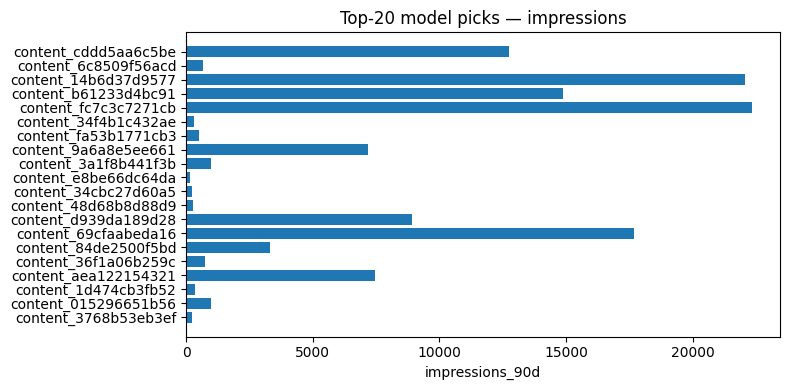

In [4]:
# Save dated export and a simple figure for the paper
import matplotlib.pyplot as plt
from datetime import datetime
fname = f"work/outputs/top20_for_playbook_{datetime.utcnow().strftime('%Y%m%d')}.csv"
top20.to_csv(fname, index=False)
print("Saved dated top20:", fname)

if 'impressions_90d' in top20.columns:
    fig, ax = plt.subplots(figsize=(8,4))
    ax.barh(top20['content_id'].astype(str).iloc[::-1], top20['impressions_90d'].iloc[::-1])
    ax.set_xlabel('impressions_90d')
    ax.set_title('Top-20 model picks — impressions')
    fig.tight_layout()
    fig_path = "work/figures/top20_impressions.png"
    fig.savefig(fig_path, dpi=150)
    print("Saved figure to", fig_path)
    plt.show()
else:
    print("impressions_90d not available for plotting")

# ***Top-20 manual review notes***   (one-line each) Ⓜ
- **content_cddd5aa6c5be** — High impressions and engagement; model + label agree. Likely correct pick.


- **content_6c8509f56acd** —Label=1 but engagement 0: check raw trend_pct/timing; possible label noise.


- **content_14b6d37d9577** — Very high impressions; likely correct.


- **content_b61233d4bc91** — Strong visibility; likely true positive.


- **content_fc7c3c7271cb** — High impressions + zero engagement; check engagement missingness or label timing.


- **content_34f4b1c432ae** — Low impressions but labeled 1 — inspect recent drop or label noise.


- **content_fa53b1771cb3** — Moderate impressions, label=1 with zero engagement — check label calc.


- **content_9a6a8e5ee661** — High impressions & very high engagement; likely true positive.


- **content_3a1f8b441f3b** — Moderate impressions, label=1 with zero engagement — verify data completeness.


- **content_e8be66dc64da** — Low impressions flagged as declining — inspect raw trend.


- **content_34cbc27d60a5** — Small page flagged — check label / source of drop.


- **content_48d68b8d88d9** — Low-impression flagged; validate label or data.


- **content_d939da189d28** — High impressions & engagement: likely correct.


- **content_69cfaabeda16** — Strong visibility: probably correct pick.


- **content_84de2500f5bd** — Medium impressions + zero engagement; check analytics completeness.


- **content_36f1a06b259c** — Moderate metrics, agree with label.


- **content_aea122154321** — High impressions & zero engagement; investigate missing engagement.


- **content_1d474cb3fb52** — Low-impression flagged as declining; inspect label window.


- **content_015296651b56** — Moderate impressions, zero engagement; check raw signals.


- **content_3768b53eb3ef** — Model predicts high but label=0 — false positive example; investigate label correctness or remaining model bias.

# ***SELF CHECK*** ⚓

Before committing:

- [ ] top-20 CSV exported to work/outputs and visually inspected

- [ ] top-20 manual notes added into the notebook (one line per false positive/negative)

- [ ] Figures saved to work/figures/ (if used in paper)

- [ ] Notebook executed top→bottom with no errors


**When done:**

File → Save a copy in GitHub → repo shaikhabdullahwaseem17-byte/vigilant-meme → branch main → filename work/notebooks/w07_action_playbook.ipynb → Commit


**Commit message suggestion**:  "w07: content action playbook, exported top-20 queue"